# Scripts to model the thermal anomalies from shear-wave velocity reductions
See Methods section in the manuscript for detailed description of the method and parameters. I also tried to provide inline comments as many as possible on the source and justification of the modeling parameters.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


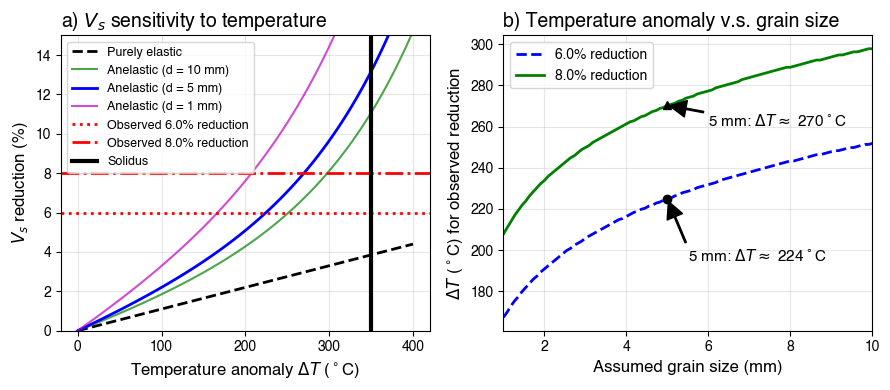

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rc('font', family='Helvetica')

# --- Physics Functions ---

def get_vs_reduction(dT, d_mm, mode='anelastic',T_base=1100,T_solidus=1450):
    """
    Calculates Vs reduction based on the 'pre-melt' scaling framework 
    of Yamauchi & Takei (2016, 2024).
    """
    # T_base = 1100  # Cratonic (relatively cold) background temp in Celsius at ~140km depth
    T = T_base + dT
    
    # Anharmonic (Elastic) baseline sensitivity
    # S_elastic = dlnVs / dT. Value of 1.1e-4 K^-1 is derived from 
    # mineral physics data for olivine-rich mantle (e.g., Goes et al., 2000).
    S_elastic = 1.1e-4 
    dvs_elastic = S_elastic * dT * 100 
    
    if mode == 'elastic':
        return dvs_elastic
        
    # add anelastic corrections.
    # Average multiplier over the temperature range to approximate the integral 
    # of sensitivity.
    M_avg = (get_multiplier(T_base, d_mm, T_solidus=T_solidus) + get_multiplier(T, d_mm, T_solidus=T_solidus)) / 2.0
    dvs_out = dvs_elastic * M_avg

    #
    return dvs_out
#
def get_multiplier(temp, grain_size,T_solidus=1450):
    """2. Anelastic multiplier (M) based on Yamauchi & Takei (2016, 2024)
    M represents the amplification of seismic sensitivity due to grain-boundary 
    relaxation. M increases non-linearly as T approaches the solidus (T_sol).
    T_sol is assumed ~1450C at this depth (140 km in our study). The exponential term approximates 
    the 'pre-melt' enhancement where relaxation time decreases rapidly.
    Framework: Yamauchi & Takei (2016), JGR: Solid Earth.
    This is a simplified equations to represent the new model they proposed, as shown in their Figure 20. 
    This equation converts the model fit in their figure to a function on the temperature difference (or deviation) from the solidus T.
    It tries to describe the exponential increase in dVs and dT when getting closer to the solidus T. Specicially, it looks at the range
    of homologous T from 0.92 to 1. 

    Figure 20 in their paper has the rapid bending from 1200 to 1350 (approximately), where 1350 is the solidus temperature in their model.
    
    """
    T_sol = T_solidus
    M_base = 1.5 + 3.5 * np.exp((temp - T_sol) / 150.0)
    
    # Grain size scaling: Anelasticity is grain-size dependent. 
    # Following the Burgers model scaling in Yamauchi & Takei, 
    # sensitivity scales roughly with d^-p, where p is typically 0.2-0.3 
    # for upper mantle conditions (Jackson & Faul, 2010; Yamauchi & Takei, 2024).
    p=0.25 #between 0.2-0.3.
    
    grain_scaling = (5.0 / grain_size)**p

    #
    M_out = M_base * grain_scaling
    
    return M_out
def solve_for_dT(target_red, d_mm,T_base,T_solidus):
    """
    Inversion: Finds the required temperature anomaly (dT) to achieve 
    the seismic velocity reduction observed in the tomography.
    """
    dTs = np.linspace(1, 600, 1200)
    for dt in dTs:
        if get_vs_reduction(dt, d_mm, mode='anelastic',T_base=T_base,T_solidus=T_solidus) >= target_red:
            return dt
    return None

# --- Data Generation ---

dT_range = np.linspace(0, 400, 100)
grain_sizes = np.linspace(1, 10, 100)

# Observed shear-wave velocity reductions from this study's tomography model
target_obs_max = 8.0 
target_obs_min = 6.0 

T_base = 1100 #cold cratonic lithosphere at 140 km
T_solidus = 1450 #at 140 km or 4.5 Gpa, with 0.05 wt% water. See Fig 6 in Katz (2003).

# Data for Plot 1: Vs Sensitivity
red_el = [get_vs_reduction(dt, 5.0, mode='elastic',T_base=T_base,T_solidus=T_solidus) for dt in dT_range]
red_ane_5mm = [get_vs_reduction(dt, 5.0, mode='anelastic',T_base=T_base,T_solidus=T_solidus) for dt in dT_range]
red_ane_1mm = [get_vs_reduction(dt, 1.0, mode='anelastic',T_base=T_base,T_solidus=T_solidus) for dt in dT_range]
red_ane_10mm = [get_vs_reduction(dt, 10.0, mode='anelastic',T_base=T_base,T_solidus=T_solidus) for dt in dT_range]

# Data for Plot 2: Thermal Interpretation
# Shows how the required dT depends on the assumed mantle grain size (1-10 mm).
required_dT_max = [solve_for_dT(target_obs_max, d,T_base=T_base,T_solidus=T_solidus) for d in grain_sizes]
required_dT_min = [solve_for_dT(target_obs_min, d,T_base=T_base,T_solidus=T_solidus) for d in grain_sizes]

# --- Plotting ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9., 4.))

# Plot 1: Vs Reduction vs. Temperature
ax1.plot(dT_range, red_el, 'k--', label='Purely elastic', linewidth=2)
ax1.plot(dT_range, red_ane_10mm, 'g-', label='Anelastic (d = 10 mm)', linewidth=1.5, alpha=0.7)
ax1.plot(dT_range, red_ane_5mm, 'b-', label='Anelastic (d = 5 mm)', linewidth=2)
ax1.plot(dT_range, red_ane_1mm, 'm-', label='Anelastic (d = 1 mm)', linewidth=1.5, alpha=0.7)

ax1.axhline(y=target_obs_min, color='r', linestyle=':', lw=2, label=f'Observed {target_obs_min}% reduction')
ax1.axhline(y=target_obs_max, color='r', linestyle='-.', lw=2, label=f'Observed {target_obs_max}% reduction')

ax1.axvline(x=T_solidus - T_base, color='k',lw=3, label = 'Solidus')
ax1.set_xlabel(r'Temperature anomaly $\Delta T$ ($^\circ$C)', fontsize=12)
ax1.set_ylabel('$V_s$ reduction (%)', fontsize=12)
ax1.set_title(r'a) $V_s$ sensitivity to temperature', fontsize=14, loc='left')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 15)

# Plot 2: Required dT vs. Grain Size
ax2.plot(grain_sizes, required_dT_min, 'b--', linewidth=2., label=f'{target_obs_min}% reduction')
ax2.plot(grain_sizes, required_dT_max, 'g-', linewidth=2., label=f'{target_obs_max}% reduction')
ax2.set_xlabel('Assumed grain size (mm)', fontsize=12)
ax2.set_ylabel(r'$\Delta T$ ($^\circ$C) for observed reduction', fontsize=12)
ax2.set_title('b) Temperature anomaly v.s. grain size', fontsize=14, loc='left')

# Highlight interpretation at 5 mm (representative mantle grain size)
# Justification: 5 mm is the standard for reconciling seismic/lab data (Jackson & Faul, 2010).
dt_at_5_min = solve_for_dT(target_obs_min, 5.0,T_base=T_base,T_solidus=T_solidus)
dt_at_5_max = solve_for_dT(target_obs_max, 5.0,T_base=T_base,T_solidus=T_solidus)
ax2.plot(5.0, dt_at_5_min, 'ko')
ax2.plot(5.0, dt_at_5_max, 'k^')
ax2.annotate(r'5 mm: $\Delta T \approx$ %d$^\circ$C'%(dt_at_5_min), 
             xy=(5.0, dt_at_5_min), xytext=(5.5, dt_at_5_min - 30),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontsize=11)
ax2.annotate(r'5 mm: $\Delta T \approx$ %d$^\circ$C'%(dt_at_5_max), 
             xy=(5.0, dt_at_5_max), xytext=(6, dt_at_5_max - 10),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontsize=11)

ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, 10)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('temperature_anomaly_dV.pdf', dpi=300)
plt.show()